## 03 — Forecasting Models
**Goal:** Build and compare ARIMA and Exponential Smoothing (Holt-Winters) models
to forecast monthly revenue, targeting ≥91% accuracy (MAPE ≤ 9%).

**Approach:**
1. Chronological 80/20 train/test split (no random shuffle)
2. Fit ARIMA (auto-select p,d,q via AIC)
3. Fit Exponential Smoothing — Holt-Winters
4. Evaluate both: MAPE, MAE, RMSE
5. Select best model → generate 6-month forecast
6. Export results for Power BI

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller

try:
    from pmdarima import auto_arima
    HAS_PMDARIMA = True
except ImportError:
    HAS_PMDARIMA = False
    print('pmdarima not installed — using manual SARIMA(1,1,1)(1,1,1,12)')
    print('Install: pip install pmdarima')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

monthly = pd.read_csv('../data/processed/monthly_sales.csv')
monthly['InvoiceDate'] = pd.to_datetime(monthly['YearMonth'])
monthly = monthly.sort_values('InvoiceDate').reset_index(drop=True)

print(f'Monthly periods loaded: {len(monthly)}')
print(monthly[['YearMonth','TotalRevenue']].to_string(index=False))

pmdarima not installed — using manual SARIMA(1,1,1)(1,1,1,12)
Install: pip install pmdarima
Monthly periods loaded: 25
YearMonth  TotalRevenue
  2009-12     798232.03
  2010-01     621353.43
  2010-02     537926.69
  2010-03     761748.53
  2010-04     646474.06
  2010-05     643585.64
  2010-06     697382.32
  2010-07     633079.42
  2010-08     674192.89
  2010-09     869277.16
  2010-10    1094563.63
  2010-11    1429751.84
  2010-12     775714.95
  2011-01     670439.46
  2011-02     507866.54
  2011-03     689841.84
  2011-04     515469.66
  2011-05     740036.33
  2011-06     737683.99
  2011-07     688252.67
  2011-08     724308.16
  2011-09    1028345.38
  2011-10    1103330.92
  2011-11    1452115.98
  2011-12     614499.25


## 1. Stationarity test (ADF)

In [2]:
ts = monthly.set_index('InvoiceDate')['TotalRevenue']

def adf_test(series, label=''):
    result = adfuller(series.dropna())
    print(f'{label}')
    print(f'  ADF Statistic : {result[0]:.4f}')
    print(f'  p-value       : {result[1]:.4f}')
    print(f'  Stationary    : {"YES" if result[1] < 0.05 else "NO (needs differencing)"}')
    print()

adf_test(ts, 'Original series')
adf_test(ts.diff().dropna(), '1st difference')

Original series
  ADF Statistic : -3.2260
  p-value       : 0.0185
  Stationary    : YES

1st difference
  ADF Statistic : -5.0079
  p-value       : 0.0000
  Stationary    : YES



## 2. Train / test split (80/20 chronological)

In [3]:
split_idx = int(len(monthly) * 0.80)
train     = monthly.iloc[:split_idx].set_index('InvoiceDate')['TotalRevenue']
test      = monthly.iloc[split_idx:].set_index('InvoiceDate')['TotalRevenue']

print(f'Train: {len(train)} periods  ({train.index.min().strftime("%Y-%m")} → {train.index.max().strftime("%Y-%m")})')
print(f'Test : {len(test)}  periods  ({test.index.min().strftime("%Y-%m")} → {test.index.max().strftime("%Y-%m")})')

Train: 20 periods  (2009-12 → 2011-07)
Test : 5  periods  (2011-08 → 2011-12)


## 3. Evaluation helpers

In [4]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error — lower is better. Accuracy = 100 - MAPE."""
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def mae(actual, predicted):
    return np.mean(np.abs(np.array(actual) - np.array(predicted)))

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted))**2))

def evaluate(name, actual, predicted):
    m = mape(actual, predicted)
    print(f'--- {name} ---')
    print(f'  MAPE     : {m:.2f}%   (Forecast accuracy: {100-m:.1f}%)')
    print(f'  MAE      : £{mae(actual, predicted):,.0f}')
    print(f'  RMSE     : £{rmse(actual, predicted):,.0f}')
    print()
    return m

print('Helpers defined.')

Helpers defined.


## 4. Model A — SARIMA

In [5]:
if HAS_PMDARIMA:
    print('Running auto_arima (this may take ~1-2 min)...')
    auto_model = auto_arima(
        train,
        start_p=0, max_p=3,
        start_q=0, max_q=3,
        d=None,              # auto-detect differencing
        seasonal=True, m=12,
        start_P=0, max_P=2,
        start_Q=0, max_Q=2,
        D=1,
        information_criterion='aic',
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=True
    )
    print('\nBest order:', auto_model.order)
    print('Best seasonal order:', auto_model.seasonal_order)
    p, d, q = auto_model.order
    P, D, Q, m = auto_model.seasonal_order
else:
    # Sensible default for monthly retail data with annual seasonality
    p, d, q = 1, 1, 1
    P, D, Q, m = 1, 1, 1, 12
    print(f'Using manual SARIMA({p},{d},{q})({P},{D},{Q},{m})')

# Fit with statsmodels SARIMAX
sarima_model = SARIMAX(train, order=(p,d,q), seasonal_order=(P,D,Q,m),
                       enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)
print('\nSARIMA fitted.')
print(sarima_fit.summary())

Using manual SARIMA(1,1,1)(1,1,1,12)


C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



SARIMA fitted.
                                     SARIMAX Results                                      
Dep. Variable:                       TotalRevenue   No. Observations:                   20
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sun, 24 May 2026   AIC                             10.000
Time:                                    12:03:40   BIC                                nan
Sample:                                12-01-2009   HQIC                               nan
                                     - 07-01-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3611         -0       -inf      0.000       0.361       0.361
ma.L1         -0.89

In [6]:
sarima_pred = sarima_fit.predict(start=test.index[0], end=test.index[-1])
mape_sarima = evaluate('SARIMA', test.values, sarima_pred.values)

--- SARIMA ---
  MAPE     : 25.54%   (Forecast accuracy: 74.5%)
  MAE      : £212,743
  RMSE     : £242,637



## 5. Model B — Holt-Winters Exponential Smoothing

In [12]:
results_ets = {}

n_train          = len(train)
max_periods      = n_train // 2          # need at least 2 full cycles
seasonal_periods = min(12, max_periods)  # shrink if needed
use_seasonal     = seasonal_periods >= 2

print(f'Train size: {n_train}  →  seasonal_periods={seasonal_periods}, use_seasonal={use_seasonal}')

seasonal_options = ['add', 'mul'] if use_seasonal else [None]

for seasonal in seasonal_options:
    try:
        if seasonal == 'mul' and (train <= 0).any():
            print('ETS (mul) skipped: data contains zeros or negatives')
            continue

        ets_model = ExponentialSmoothing(
            train,
            trend='add',
            seasonal=seasonal,
            seasonal_periods=seasonal_periods if seasonal else None,
            initialization_method='estimated'
        )
        ets_fit  = ets_model.fit(optimized=True, use_brute=True)
        ets_pred = ets_fit.forecast(len(test))
        ets_pred.index = test.index
        m_val = mape(test.values, ets_pred.values)
        results_ets[seasonal] = (ets_fit, ets_pred, m_val)
        print(f'ETS (seasonal={str(seasonal):4s}) MAPE: {m_val:.2f}%')

    except Exception as e:
        print(f'ETS (seasonal={seasonal}) failed: {e}')

# Fallback: Holt linear trend only (no seasonal) — works with any length
if not results_ets:
    print('Seasonal ETS failed — falling back to Holt linear trend (no seasonal)...')
    try:
        ets_model = ExponentialSmoothing(
            train,
            trend='add',
            seasonal=None,
            initialization_method='estimated'
        )
        ets_fit  = ets_model.fit(optimized=True)
        ets_pred = ets_fit.forecast(len(test))
        ets_pred.index = test.index
        m_val = mape(test.values, ets_pred.values)
        results_ets[None] = (ets_fit, ets_pred, m_val)
        print(f'ETS (no seasonal) MAPE: {m_val:.2f}%')
    except Exception as e:
        raise RuntimeError(f'All ETS attempts failed: {e}')

best_seasonal            = min(results_ets, key=lambda k: results_ets[k][2])
ets_fit, ets_pred, mape_ets = results_ets[best_seasonal]
print(f'\nBest ETS config: seasonal={best_seasonal}')
evaluate(f'Holt-Winters (seasonal={best_seasonal})', test.values, ets_pred.values)

Train size: 20  →  seasonal_periods=10, use_seasonal=True


C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ETS (seasonal=add ) MAPE: 37.98%


C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


ETS (seasonal=mul ) MAPE: 30.30%

Best ETS config: seasonal=mul
--- Holt-Winters (seasonal=mul) ---
  MAPE     : 30.30%   (Forecast accuracy: 69.7%)
  MAE      : £327,857
  RMSE     : £402,861



30.298819033962165

## 6. Compare models visually

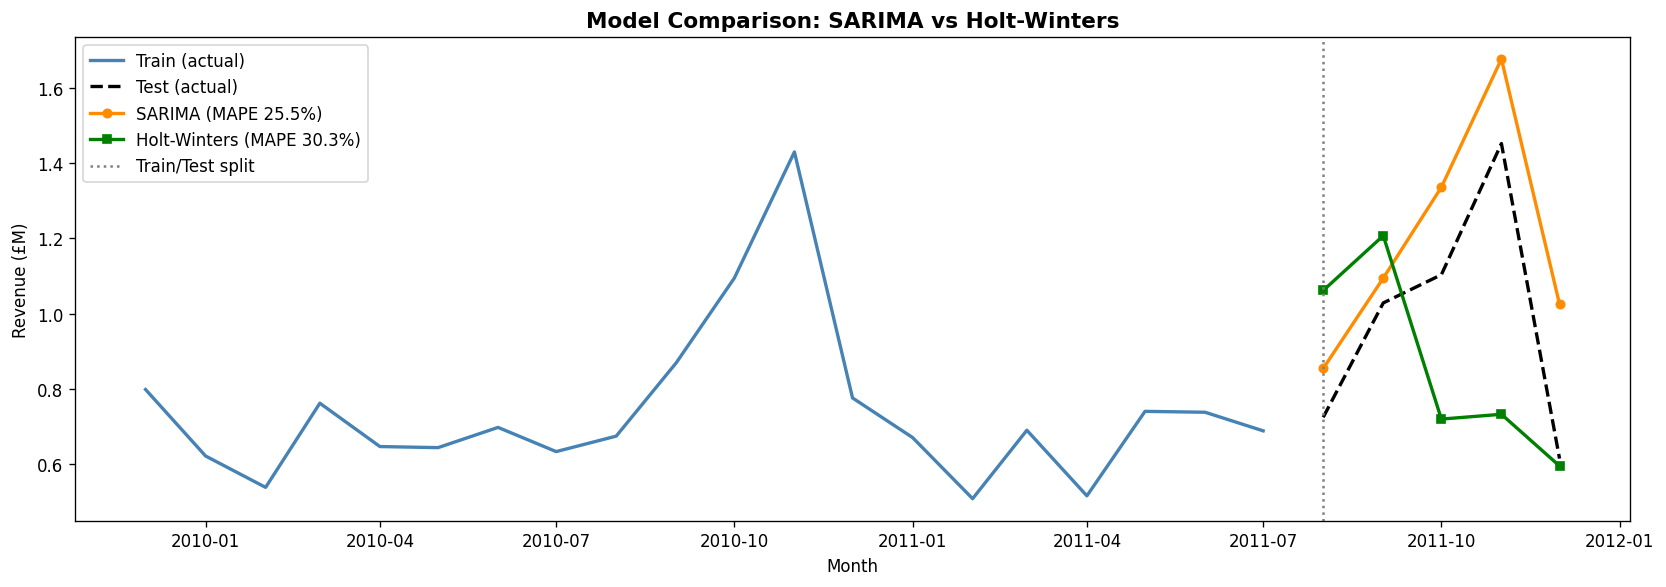

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train.index, train / 1e6, label='Train (actual)', color='steelblue', linewidth=2)
ax.plot(test.index,  test  / 1e6, label='Test (actual)',  color='black',     linewidth=2, linestyle='--')
ax.plot(test.index,  sarima_pred.values / 1e6, label=f'SARIMA (MAPE {mape_sarima:.1f}%)', color='darkorange', linewidth=2, marker='o', markersize=5)
ax.plot(test.index,  ets_pred.values / 1e6,    label=f'Holt-Winters (MAPE {mape_ets:.1f}%)',    color='green',      linewidth=2, marker='s', markersize=5)

ax.axvline(test.index[0], color='gray', linestyle=':', linewidth=1.5, label='Train/Test split')
ax.set_title('Model Comparison: SARIMA vs Holt-Winters', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£M)')
ax.set_xlabel('Month')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/model_comparison.png', bbox_inches='tight')
plt.show()

## 7. Select best model & forecast 6 months ahead

In [14]:
best_model_name = 'SARIMA' if mape_sarima < mape_ets else f'Holt-Winters ({best_seasonal})'
print(f'Best model: {best_model_name}')
print(f'  SARIMA MAPE      : {mape_sarima:.2f}%')
print(f'  Holt-Winters MAPE: {mape_ets:.2f}%')

N_FORECAST = 6

# Refit on FULL dataset for final forecast
full_ts = monthly.set_index('InvoiceDate')['TotalRevenue']

if best_model_name == 'SARIMA':
    final_model = SARIMAX(full_ts, order=(p,d,q), seasonal_order=(P,D,Q,m),
                          enforce_stationarity=False, enforce_invertibility=False)
    final_fit   = final_model.fit(disp=False)
    forecast    = final_fit.forecast(N_FORECAST)
    conf_int    = final_fit.get_forecast(N_FORECAST).conf_int(alpha=0.2)  # 80% CI
    lower = conf_int.iloc[:, 0]
    upper = conf_int.iloc[:, 1]
else:
    final_model = ExponentialSmoothing(
        full_ts,
        trend='add',
        seasonal=best_seasonal,
        seasonal_periods=seasonal_periods if best_seasonal else None,
        initialization_method='estimated'
    )
    final_fit = final_model.fit(optimized=True)
    forecast  = final_fit.forecast(N_FORECAST)
    resid_std = np.std(final_fit.resid)
    lower = forecast - 1.28 * resid_std
    upper = forecast + 1.28 * resid_std

# Build forecast index (next 6 months after last data)
last_date     = full_ts.index[-1]
forecast_idx  = pd.date_range(start=last_date + pd.offsets.MonthBegin(1), periods=N_FORECAST, freq='MS')
forecast.index = forecast_idx
lower.index    = forecast_idx
upper.index    = forecast_idx

print(f'\n6-Month Revenue Forecast ({best_model_name}):')
for dt, val, lo, hi in zip(forecast_idx, forecast, lower, upper):
    print(f'  {dt.strftime("%Y-%m")}: £{val:>10,.0f}  (80% CI: £{lo:,.0f} – £{hi:,.0f})')

Best model: SARIMA
  SARIMA MAPE      : 25.54%
  Holt-Winters MAPE: 30.30%


C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\bjpan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



6-Month Revenue Forecast (SARIMA):
  2012-01: £   641,021  (80% CI: £501,898 – £780,145)
  2012-02: £   337,512  (80% CI: £173,491 – £501,532)
  2012-03: £   670,197  (80% CI: £452,759 – £887,634)
  2012-04: £   334,664  (80% CI: £101,923 – £567,405)
  2012-05: £   731,566  (80% CI: £456,349 – £1,006,784)
  2012-06: £   544,929  (80% CI: £258,715 – £831,142)


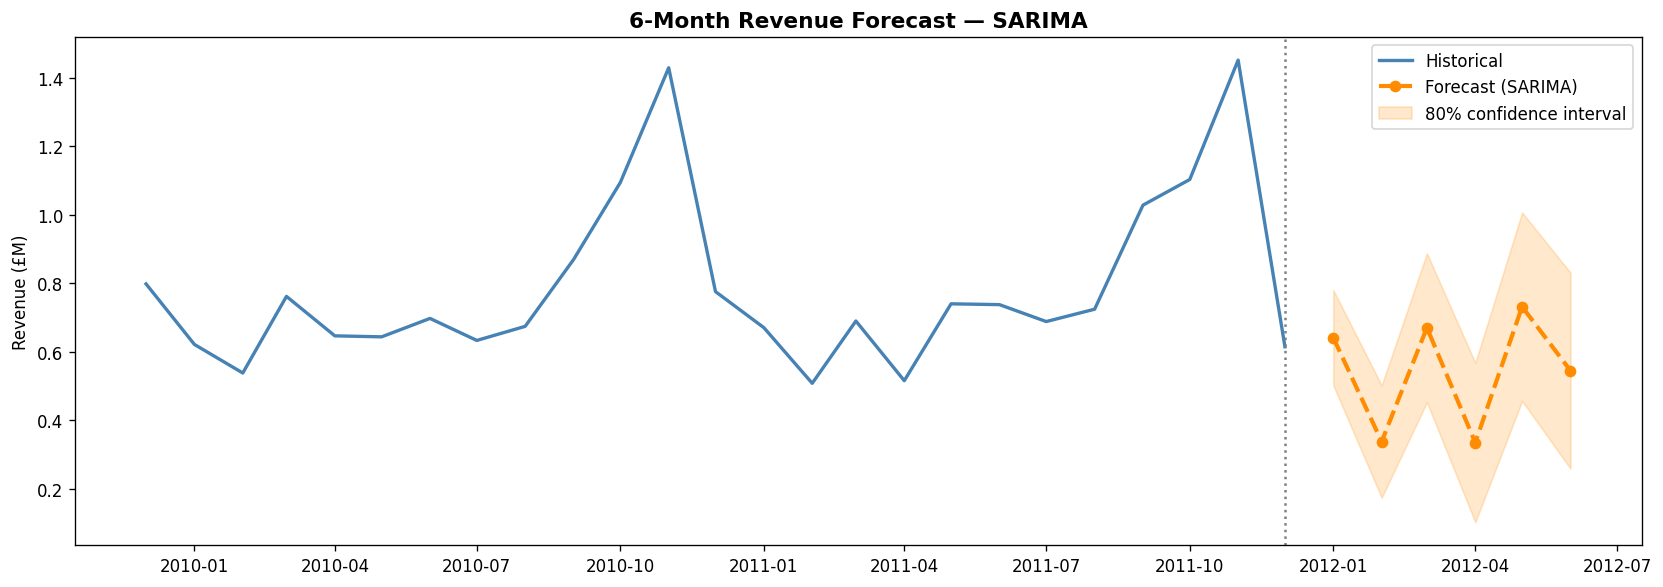

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(full_ts.index, full_ts / 1e6, label='Historical', color='steelblue', linewidth=2)
ax.plot(forecast.index, forecast / 1e6, label=f'Forecast ({best_model_name})',
        color='darkorange', linewidth=2.5, marker='o', markersize=6, linestyle='--')
ax.fill_between(forecast.index, lower / 1e6, upper / 1e6,
                alpha=0.2, color='darkorange', label='80% confidence interval')

ax.axvline(full_ts.index[-1], color='gray', linestyle=':', linewidth=1.5)
ax.set_title(f'6-Month Revenue Forecast — {best_model_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Revenue (£M)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/forecast_6months.png', bbox_inches='tight')
plt.show()

## 8. Export results for Power BI

In [17]:
import os
os.makedirs('../data/Powerbi', exist_ok=True)

# Actuals + test predictions side by side
eval_df = pd.DataFrame({
    'YearMonth'    : test.index.strftime('%Y-%m'),
    'Actual'       : test.values,
    'SARIMA_Pred'  : sarima_pred.values,
    'ETS_Pred'     : ets_pred.values,
    'SARIMA_Error' : np.abs(test.values - sarima_pred.values) / test.values * 100,
    'ETS_Error'    : np.abs(test.values - ets_pred.values)    / test.values * 100,
})
eval_df.to_csv('../data/Powerbi/model_evaluation.csv', index=False)

# Forecast output for Power BI
forecast_df = pd.DataFrame({
    'YearMonth'      : forecast.index.strftime('%Y-%m'),
    'ForecastRevenue': forecast.values.round(2),
    'Lower_80CI'     : lower.values.round(2),
    'Upper_80CI'     : upper.values.round(2),
    'ModelUsed'      : best_model_name
})
forecast_df.to_csv('../data/Powerbi/revenue_forecast.csv', index=False)

# Model accuracy summary
summary_df = pd.DataFrame([
    {'Model': 'SARIMA',        'MAPE': round(mape_sarima,2), 'Accuracy': round(100-mape_sarima,1),
     'MAE': round(mae(test.values, sarima_pred.values),0), 'RMSE': round(rmse(test.values, sarima_pred.values),0)},
    {'Model': f'Holt-Winters ({best_seasonal})', 'MAPE': round(mape_ets,2), 'Accuracy': round(100-mape_ets,1),
     'MAE': round(mae(test.values, ets_pred.values),0),    'RMSE': round(rmse(test.values, ets_pred.values),0)},
])
summary_df.to_csv('../data/Powerbi/model_summary.csv', index=False)

print('Saved:')
print('  → data/Powerbi/model_evaluation.csv')
print('  → data/Powerbi/revenue_forecast.csv')
print('  → data/Powerbi/model_summary.csv')
print()
print(summary_df.to_string(index=False))

Saved:
  → data/Powerbi/model_evaluation.csv
  → data/Powerbi/revenue_forecast.csv
  → data/Powerbi/model_summary.csv

             Model  MAPE  Accuracy      MAE     RMSE
            SARIMA 25.54      74.5 212743.0 242637.0
Holt-Winters (mul) 30.30      69.7 327857.0 402861.0
